# 520 — Design an analysis you can explain
Companion to [six AI-guided lessons](../lessons/520.md), with [answer keys](../answer_keys/520.md) and [sources](../sources/520.md).

All inputs are synthetic; no network access or external files are used. Dependencies: NumPy, SciPy, Matplotlib. Run each section's cells in order. Each section imports its own dependencies and can start in a fresh kernel. Every code cell contains at most 20 lines. Predict before running, then explain a result in ordinary language. Deliberate failures are displayed and checked without causing Run All to stop.

These are learning models. In particular, ordinary least-squares uncertainty below assumes iid normal errors. Real fMRI inference needs a temporal-noise model and an appropriate preprocessing and inference workflow. The illustrative HRF is not an exact SPM/FSL implementation. Synthetic independent voxels do not reproduce spatial brain noise.


## 1. The person is not the row
**Predict:** Three people have values 0, 1, 3 and row counts 1, 1, 8. What is the mean person? What is the mean row? Input: participant values and row counts. Output: two differently weighted estimates.


People: 3 Rows: 10
Mean person / mean row: 1.3333333333333333 2.5


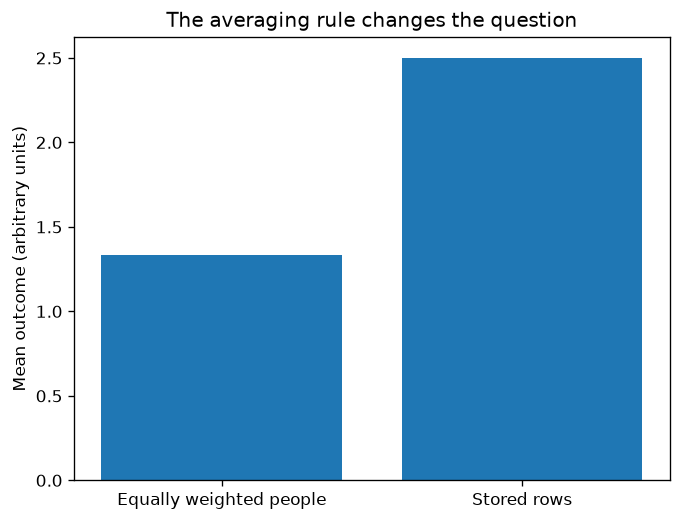

In [1]:
import numpy as np
import matplotlib.pyplot as plt
values = np.array([0., 1., 3.])
row_counts = np.array([1, 1, 8])
ids = np.repeat(np.arange(3), row_counts)
rows = np.repeat(values, row_counts)
person_mean, row_mean = values.mean(), rows.mean()
print('People:', np.unique(ids).size, 'Rows:', rows.size)
print('Mean person / mean row:', person_mean, row_mean)
assert np.isclose(person_mean, 4 / 3)
assert np.isclose(row_mean, 2.5)
plt.bar(['Equally weighted people', 'Stored rows'], [person_mean, row_mean])
plt.ylabel('Mean outcome (arbitrary units)')
plt.title('The averaging rule changes the question')
plt.show()


**Break it:** duplicate each of 12 participant values 20 times and pretend all rows are independent. Does the experiment now contain 240 people? The naive standard error will be artificially smaller. Our intentionally identical repeats make the failure especially easy to see.


In [2]:
person_values = np.linspace(-1, 1.2, 12)
repeated_rows = np.repeat(person_values, 20)
se_people = person_values.std(ddof=1) / np.sqrt(person_values.size)
se_wrong = repeated_rows.std(ddof=1) / np.sqrt(repeated_rows.size)
print('12-person SE:', round(se_people, 4))
print('Wrong 240-independent-row SE:', round(se_wrong, 4))
assert np.isclose(person_values.mean(), repeated_rows.mean())
assert se_wrong < se_people / 4
print('PASS: duplication changes naive precision, not participant information.')


12-person SE: 0.2082
Wrong 240-independent-row SE: 0.0447
PASS: duplication changes naive precision, not participant information.


## 2. Site confounding and paired identity
**Predict:** We generate outcome = 2 × site + 0.5 × group, without noise. Both groups occur at both sites, but their proportions differ. Will the raw group difference equal 0.5? The exact recovery here depends on this deliberately complete, correct additive model.


In [3]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
site = np.array([0, 0, 0, 0, 1, 1, 1, 1])
group = np.array([0, 0, 0, 1, 0, 1, 1, 1])
y = 2.0 * site + 0.5 * group
X = np.column_stack([np.ones(8), group, site])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
raw = y[group == 1].mean() - y[group == 0].mean()
print('Raw difference / adjusted group coefficient:', raw, beta[1])
assert np.isclose(raw, 1.5) and np.isclose(beta[1], 0.5)
bad_X = np.column_stack([np.ones(8), group, group])
assert np.linalg.matrix_rank(bad_X) < bad_X.shape[1]
print('Perfect group/site confounding gives rank', np.linalg.matrix_rank(bad_X))


Raw difference / adjusted group coefficient: 1.5 0.5000000000000004
Perfect group/site confounding gives rank 2


**Pair audit:** The same person owns each before/after pair. Reversing after-values preserves the marginal means, but destroys identity and changes uncertainty. Predict the effect on each person's difference before running.


Correct changes: [0.8 1.2 0.9 1.1]
Incorrectly paired changes: [ 23.1   8.9  -6.8 -21.2]
Their means: 1.0000000000000002 1.0


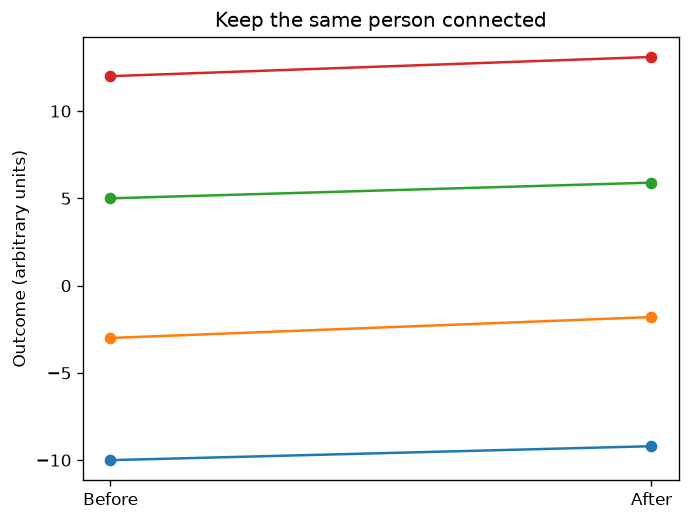

In [4]:
before = np.array([-10., -3., 5., 12.])
after = before + np.array([0.8, 1.2, 0.9, 1.1])
difference = after - before
wrong_difference = after[::-1] - before
print('Correct changes:', difference)
print('Incorrectly paired changes:', wrong_difference)
print('Their means:', difference.mean(), wrong_difference.mean())
assert np.isclose(difference.mean(), wrong_difference.mean())
assert wrong_difference.std(ddof=1) > 20 * difference.std(ddof=1)
plt.plot(np.column_stack([before, after]).T, marker='o')
plt.xticks([0, 1], ['Before', 'After'])
plt.ylabel('Outcome (arbitrary units)')
plt.title('Keep the same person connected')
plt.show()


**Allowed relabelling:** enumerate all 2⁴ within-pair sign flips. For an appropriate randomized paired experiment, labels can be swapped within each pair under the null. An observational sign-flip test instead needs symmetric independent differences under its null. Arbitrary shuffling of correlated scan rows is not justified by this example.


In [5]:
signs = np.array(list(itertools.product([-1, 1], repeat=4)))
null_means = (signs * difference).mean(axis=1)
observed = difference.mean()
p_exact = np.mean(np.abs(null_means) >= abs(observed) - 1e-12)
assert signs.shape == (16, 4)
assert np.isclose(p_exact, 2 / 16)
pairs = np.column_stack([before, after])
flipped_pairs = pairs.copy()
flip = np.array([True, False, True, False])
flipped_pairs[flip] = flipped_pairs[flip, ::-1]
assert np.allclose(np.sort(pairs, axis=1), np.sort(flipped_pairs, axis=1))
print('Exact two-sided sign-flip p:', p_exact)
print('PASS: every permitted swap retains the values owned by each person.')


Exact two-sided sign-flip p: 0.125
PASS: every permitted swap retains the values owned by each person.


## 3. Events → HRF convolution → scan-sampled design
**Predict:** The event at 10 seconds should produce a delayed broad response. Each internal sample is 1 second; scans are sampled every 2 seconds. This teaching HRF uses a difference of gamma curves and is normalized to a peak of one.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
time = np.arange(120, dtype=float)
hrf_time = np.arange(32, dtype=float)
hrf = stats.gamma.pdf(hrf_time, 6) - stats.gamma.pdf(hrf_time, 16) / 6
hrf /= hrf.max()
event_a, event_b = np.zeros(120), np.zeros(120)
event_a[[10, 30, 50, 70, 90]] = 1
event_b[[20, 40, 60, 80, 100]] = 1
pred_a = np.convolve(event_a, hrf)[:120]
pred_b = np.convolve(event_b, hrf)[:120]
TR = 2
X = np.column_stack([pred_a[::TR], pred_b[::TR], np.ones(60)])
column_names = ['A', 'B', 'intercept']
print('HRF peak lag (seconds):', hrf_time[np.argmax(hrf)])
print('Columns / shape / rank:', column_names, X.shape, np.linalg.matrix_rank(X))
assert X.shape == (60, 3) and np.linalg.matrix_rank(X) == 3
assert 0 < hrf_time[np.argmax(hrf)] < 10


HRF peak lag (seconds): 5.0
Columns / shape / rank: ['A', 'B', 'intercept'] (60, 3) 3


Failure: adding any multiple of [1,-1,0] leaves fitted values unchanged.
Repair: collect a design that separates the intended conditions.


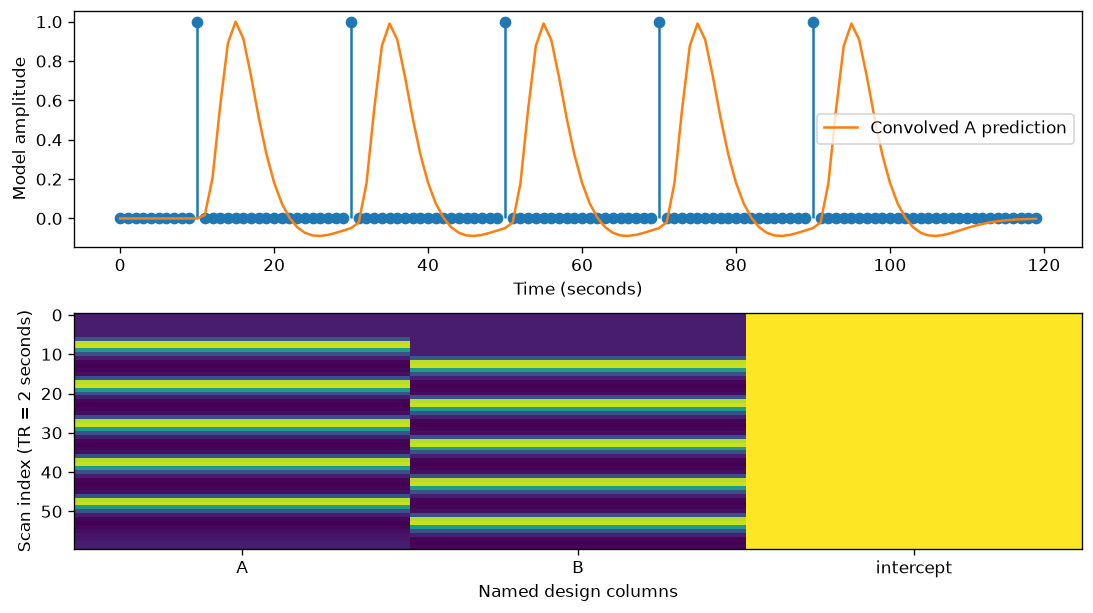

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), constrained_layout=True)
axes[0].stem(time, event_a, linefmt='C0-', markerfmt='C0o', basefmt=' ')
axes[0].plot(time, pred_a, label='Convolved A prediction', color='C1')
axes[0].set(xlabel='Time (seconds)', ylabel='Model amplitude')
axes[0].legend()
axes[1].imshow(X, aspect='auto', interpolation='nearest')
axes[1].set_xticks(range(3), column_names)
axes[1].set(xlabel='Named design columns', ylabel='Scan index (TR = 2 seconds)')
plt.show()
bad_X = np.column_stack([pred_a[::TR], pred_a[::TR], np.ones(60)])
assert np.linalg.matrix_rank(bad_X) == 2
null_direction = np.array([1., -1., 0.])
assert np.allclose(bad_X @ null_direction, 0)
print('Failure: adding any multiple of [1,-1,0] leaves fitted values unchanged.')
print('Repair: collect a design that separates the intended conditions.')


## 4. Betas, contrasts, uncertainty, t, and z
**Predict:** Multiplying a predictor by 10 changes its coefficient's units, but should not change its t statistic. This is an **iid normal-error toy**. Real fMRI scan residuals are temporally dependent; do not use this elementary standard error as a real fMRI pipeline.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(5204)
x = np.linspace(-1, 1, 80)
y = 10 + 2 * x + rng.normal(0, 1, x.size)
X = np.column_stack([np.ones(x.size), x])
columns = ['intercept', 'predictor']
c = np.array([0., 1.])
def fit_contrast(design, outcome, contrast):
    beta = np.linalg.lstsq(design, outcome, rcond=None)[0]
    residual = outcome - design @ beta
    df = len(outcome) - np.linalg.matrix_rank(design)
    variance = (residual @ residual) / df
    effect = contrast @ beta
    se = np.sqrt(variance * (contrast @ np.linalg.inv(design.T @ design) @ contrast))
    return effect, se, effect / se, df
effect, se, t_value, df = fit_contrast(X, y, c)
print(dict(zip(columns, c)), 'effect/SE/t/df:', effect, se, t_value, df)


{'intercept': np.float64(0.0), 'predictor': np.float64(1.0)} effect/SE/t/df: 2.098260900354186 0.18325380655767645 11.450026276500779 78


In [9]:
p_two = 2 * stats.t.sf(abs(t_value), df)
z_signed = np.sign(t_value) * stats.norm.isf(stats.t.sf(abs(t_value), df))
X_rescaled = np.column_stack([np.ones(x.size), 10 * x])
effect2, se2, t2, _ = fit_contrast(X_rescaled, y, c)
assert np.allclose([effect2, se2], [effect / 10, se / 10])
assert np.isclose(t2, t_value)
assert np.isclose(2 * stats.norm.sf(abs(z_signed)), p_two)
print('Two-sided p / signed tail-equivalent z:', p_two, z_signed)
print('Rescaled effect / SE / t:', effect2, se2, t2)
wrong_effect = fit_contrast(X[:, ::-1], y, c)[0]
repaired_effect = fit_contrast(X[:, ::-1], y, c[::-1])[0]
assert not np.isclose(wrong_effect, effect)
assert np.isclose(repaired_effect, effect)
print('Wrong reused contrast / repaired:', wrong_effect, repaired_effect)


Two-sided p / signed tail-equivalent z: 2.2404338248663775e-18 8.744480846140517
Rescaled effect / SE / t: 0.20982609003541863 0.018325380655767647 11.450026276500779
Wrong reused contrast / repaired: 10.044869421319039 2.098260900354183


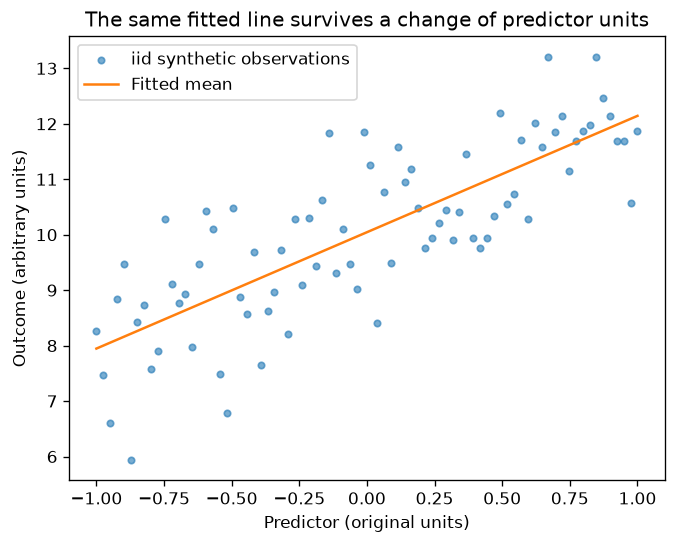

In [10]:
beta = np.linalg.lstsq(X, y, rcond=None)[0]
plt.scatter(x, y, s=15, alpha=0.6, label='iid synthetic observations')
plt.plot(x, X @ beta, color='C1', label='Fitted mean')
plt.xlabel('Predictor (original units)')
plt.ylabel('Outcome (arbitrary units)')
plt.title('The same fitted line survives a change of predictor units')
plt.legend()
plt.show()


## 5. Many null tests and circular region selection
**Predict:** Roughly 50 of 1,000 independent valid null tests will cross 0.05 uncorrected on average. Our 30 rows are independent synthetic participants, and all 1,000 locations are independent noise. Bonferroni controls family-wise error; the BH rule below controls FDR under its assumptions. This is not a spatial imaging model.


Raw / Bonferroni / BH discoveries: [np.int64(47), np.int64(0), np.int64(0)]


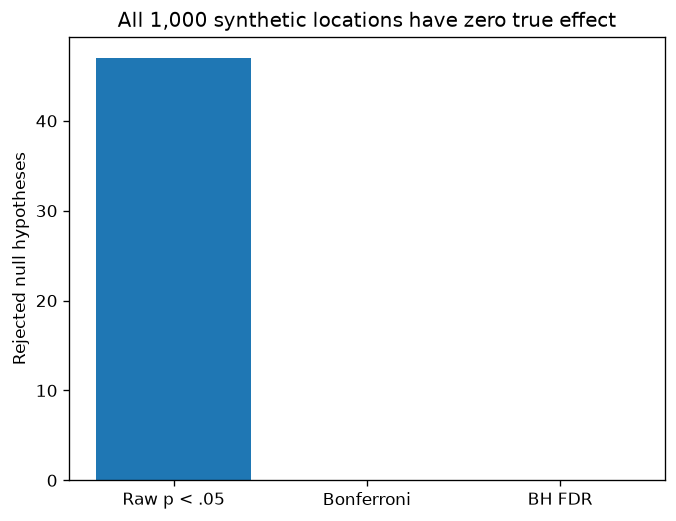

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(5205)
y = rng.normal(size=(30, 1000))
p = stats.ttest_1samp(y, 0, axis=0).pvalue
alpha, m = 0.05, p.size
order = np.argsort(p)
passes = np.flatnonzero(p[order] <= alpha * np.arange(1, m + 1) / m)
bh_cutoff = p[order[passes[-1]]] if passes.size else -1.0
counts = [np.sum(p < alpha), np.sum(p < alpha / m), np.sum(p <= bh_cutoff)]
assert counts[1] <= counts[0] and counts[2] <= counts[0]
print('Raw / Bonferroni / BH discoveries:', counts)
plt.bar(['Raw p < .05', 'Bonferroni', 'BH FDR'], counts)
plt.ylabel('Rejected null hypotheses')
plt.title('All 1,000 synthetic locations have zero true effect')
plt.show()


Inspect a location chosen **before** looking at results. A t interval is appropriate for this independent normal toy. A single 95% interval need not include zero; do not assert that it must. Then run 500 complete null discovery/replication experiments, selecting the strongest discovery location in each. The replication sample uses independent noise at that same selected location.


In [12]:
fixed_location = 0
mean0 = y[:, fixed_location].mean()
se0 = y[:, fixed_location].std(ddof=1) / np.sqrt(y.shape[0])
ci = mean0 + np.array([-1, 1]) * stats.t.ppf(0.975, 29) * se0
print('Preselected location effect / 95% t interval:', mean0, ci)
discovery = rng.normal(size=(500, 200)) / np.sqrt(30)
replication = rng.normal(size=(500, 200)) / np.sqrt(30)
selected = discovery.argmax(axis=1)
run_index = np.arange(500)
chosen_discovery = discovery[run_index, selected]
chosen_replication = replication[run_index, selected]
assert chosen_discovery.mean() > 0.3
assert abs(chosen_replication.mean()) < 0.05
print('Selected discovery / independent replication means:',
      chosen_discovery.mean(), chosen_replication.mean())


Preselected location effect / 95% t interval: -0.23724569995984374 [-0.60077679  0.12628539]
Selected discovery / independent replication means: 0.5009443938765085 0.009607074101307162


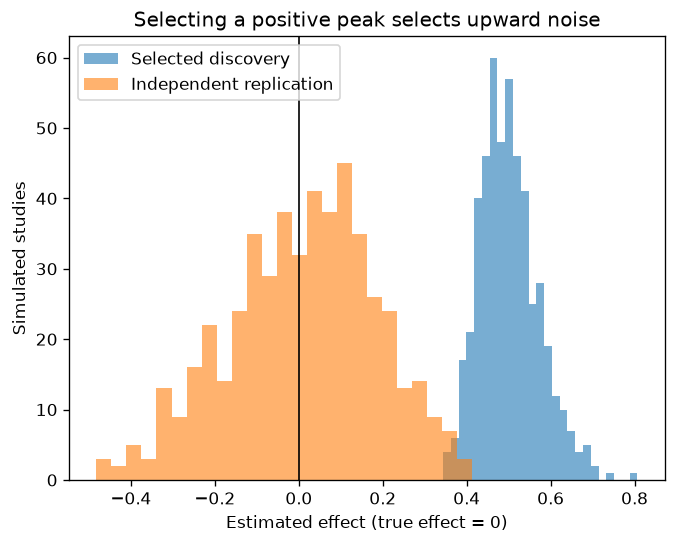

In [13]:
plt.hist(chosen_discovery, bins=25, alpha=0.6, label='Selected discovery')
plt.hist(chosen_replication, bins=25, alpha=0.6, label='Independent replication')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Estimated effect (true effect = 0)')
plt.ylabel('Simulated studies')
plt.legend()
plt.title('Selecting a positive peak selects upward noise')
plt.show()


## 6. Power, a fixed plan, and independent replication
**Predict:** More participants usually increase power at a fixed effect and noise. More Monte Carlo repetitions only improve the precision of our power estimate. Here 0.4 is an arbitrary mean difference and 1 is its standard deviation, not an empirically justified fMRI effect size. We simulate independent normal participant-level differences and use a two-sided one-sample t test.


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def power_toy(n, effect, seed, repetitions=2000):
    rng = np.random.default_rng(seed)
    differences = rng.normal(effect, 1, size=(repetitions, n))
    detected = stats.ttest_1samp(differences, 0, axis=1).pvalue < 0.05
    power = detected.mean()
    mc_se = np.sqrt(power * (1 - power) / repetitions)
    return power, mc_se
small = power_toy(20, 0.4, 5206)
large = power_toy(80, 0.4, 5206)
null = power_toy(80, 0.0, 5216)
assert large[0] > small[0] + 0.25
assert abs(null[0] - 0.05) < 0.03
print('n=20 power / MC SE:', small)
print('n=80 power / MC SE:', large)
print('Null detection rate / MC SE:', null)


n=20 power / MC SE: (np.float64(0.3875), np.float64(0.01089366214824014))
n=80 power / MC SE: (np.float64(0.9425), np.float64(0.005205465877325487))
Null detection rate / MC SE: (np.float64(0.0475), np.float64(0.004756245893559331))


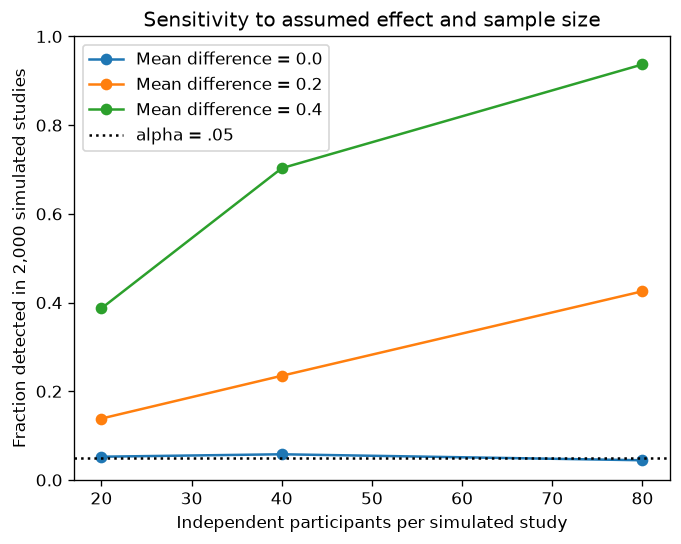

In [15]:
sizes = [20, 40, 80]
for effect in [0.0, 0.2, 0.4]:
    estimates = [power_toy(n, effect, 5300 + n)[0] for n in sizes]
    plt.plot(sizes, estimates, marker='o', label=f'Mean difference = {effect}')
plt.axhline(0.05, color='black', linestyle=':', label='alpha = .05')
plt.ylim(0, 1)
plt.xlabel('Independent participants per simulated study')
plt.ylabel('Fraction detected in 2,000 simulated studies')
plt.legend()
plt.title('Sensitivity to assumed effect and sample size')
plt.show()


**Freeze and audit:** This small local record illustrates a fixed analysis contract; it is not a complete preregistration. Expand it using the lesson's one-page plan. A computational rerun uses the same data; a toy replication below generates new people. Do not keep regenerating studies until one is significant.


In [16]:
plan = {'unit': 'participant', 'n': 80, 'contrast': 'A minus B',
        'roi': 'one region chosen independently of these outcomes',
        'test': 'two-sided one-sample t on participant differences',
        'alpha': 0.05, 'stopping': 'fixed n; no outcome-dependent extension',
        'simulation_mean': 0.4, 'simulation_sd': 1.0}
frozen_plan = json.dumps(plan, sort_keys=True)
def one_study(seed):
    values = np.random.default_rng(seed).normal(0.4, 1, plan['n'])
    return values.mean(), stats.ttest_1samp(values, 0).pvalue
original = one_study(5400)
rerun = one_study(5400)
replication = one_study(5401)
assert original == rerun
assert original != replication
assert json.dumps(plan, sort_keys=True) == frozen_plan
print('Same study / rerun / independent toy replication:')
print(original, rerun, replication)
print('Fixed plan:', frozen_plan)


Same study / rerun / independent toy replication:
(np.float64(0.29020419336296543), np.float64(0.00800017977913289)) (np.float64(0.29020419336296543), np.float64(0.00800017977913289)) (np.float64(0.39523948521861285), np.float64(7.634098964834417e-05))
Fixed plan: {"alpha": 0.05, "contrast": "A minus B", "n": 80, "roi": "one region chosen independently of these outcomes", "simulation_mean": 0.4, "simulation_sd": 1.0, "stopping": "fixed n; no outcome-dependent extension", "test": "two-sided one-sample t on participant differences", "unit": "participant"}


**Deliberate failure to discuss:** “Keep adding participants until p < .05” changes the stopping rule. Repeated use of an ordinary fixed-sample test does not preserve its nominal error rate. Repair by retaining the fixed plan, or by planning a suitable sequential procedure before outcomes are examined.

**Finish:** explain one changed quantity, one unchanged quantity, and one assumption in each section. Review [the answer key](../answer_keys/520.md) after recording your own answers.


<!-- agentic-guide -->
## Agentic Deliverable Supervision (NIIN 520 · Experimental Design, Sampling, Reliability & Multiverse Inference · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** HRF convolution & design efficiency, AR(1) GLS prewhitening, attenuation-corrected BWAS power, circularity-free ROI inference, and multiverse specification curves (`PD01–PD07`, `D01–D16`)

### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose (`Qwen`) to run and extend the Lab 520 experimental design suite—comparing jittered vs. fixed-ISI contrast efficiency, OLS vs. AR(1) GLS false-positive rates under colored fMRI noise, Spearman-Brown reliability attenuation curves, and split-half vs. circular ROI testing. Ask `Gemma 4` to audit the statistical degrees of freedom, autocorrelation covariance propagation, and selection-independence boundaries.

### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Fixed short ISIs collapse contrast efficiency on rapid event contrasts, naive OLS under AR(1) noise ($\rho \ge 0.4$) inflates nominal $\alpha = 0.05$ false positives above $0.13$–$0.25$, or ROI voxel selection on the same contrast/data inflates null $t$-statistics above $2.5$.
- **Where the Bug Entered:** Rapid unjittered ISIs cause severe HRF overlap in $(X^\top X)^{-1}$, positive $\text{AR}(1)$ residual autocorrelation makes naive $\hat{\sigma}^2(X^\top X)^{-1}$ underestimate the true sandwich variance, and selecting ROI voxels on the test contrast truncates the null distribution.
- **How to Fix It:** Add jittered null trials to separate HRF predictors, prewhiten both $y$ and $X$ by $V^{-1/2}$ so contrast variance uses $(X^\top V^{-1} X)^{-1}$, and isolate ROI selection via independent functional localizers, anatomical masks, or statistically orthogonal contrasts.

### 3. Expected Outcome Range & Why It Must Look That Way
**Expected Range:** Across Lab 520, jittered event schedules boost differential contrast efficiency by **2x to 4x**, AR(1) GLS restores empirical Type I error to **0.045–0.055**, doubling reliable scan duration reduces required sample size $N$ by **25%–40%** under Spearman attenuation $r_{\text{obs}} = r_{\text{true}}\sqrt{R_{xx}R_{yy}}$, and independent split-half ROI evaluation returns null false-positive rates to **~5%**. **Why:** Valid inference requires matching the estimator covariance to the physical data-generating process and keeping selection statistics independent of evaluation statistics.
<!-- /agentic-guide -->
